In [1]:
import AILibs

import torch 
import numpy 

import os  

dataset_root_path = "/Users/michal/datasets/imagenet_subtrain/"
dataset = AILibs.DatasetImages(dataset_root_path)

experiment_path = "results/images_features_b/"

if not os.path.exists(experiment_path + "/eda/"):
    os.makedirs(experiment_path + "/eda/")
    

model = AILibs.TinyCNNModel(in_ch = 3, num_features = 128)


model = torch.load(experiment_path + "model_final.pt", map_location="cpu", weights_only=False)
model.eval()


def model_inference(x):
    with torch.no_grad():
        x = torch.from_numpy(x).float()
            
        z = model(x)

        z = z.float().detach().cpu().numpy()

    return z

/opt/homebrew/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['n04542943', 'n02795169', 'n02422699', 'n03498962', 'n01740131', 'n02769748', 'n02319095', 'n07920052', 'n02111500', 'n02834397', 'n03457902', 'n01968897', 'n02917067', 'n04404412', 'n13052670', 'n01692333', 'n02808304', 'n01530575', 'n03724870', 'n03016953', 'n01734418', 'n04483307', 'n04505470', 'n03590841', 'n03733805', 'n02514041', 'n11879895', 'n01629819', 'n03394916', 'n07742313', 'n02058221', 'n03417042', 'n04523525', 'n04330267', 'n04336792', 'n02793495', 'n04251144', 'n04125021', 'n02814533', 'n02497673', 'n02095314', 'n02100877', 'n03476684', 'n02837789', 'n02105162', 'n03803284', 'n03045698', 'n02037110', 'n01770393', 'n01910747', 'n02643566', 'n03649909', 'n02088238', 'n04209239', 'n04584207', 'n02840245', 'n07754684', 'n02127052', 'n02124075', 'n02504013', 'n03218198', 'n02317335', 'n02089973', 'n02108422', 'n02085782', 'n02104029', 'n02992211', 'n12985857', 'n02397096', 'n02094258', 'n01774750', 'n03769881', 'n04509417', 'n06596364', 'n01860187', 'n04040759', 'n03838899'

# plot features beside example images

In [2]:
import os
import cv2
from sklearn.decomposition import PCA


def render_images(n_samples):
    result_path = experiment_path + "/eda/sample_images/"

    if not os.path.exists(result_path):
        os.makedirs(result_path)

    for n in range(n_samples):
        # obtain features
        x = dataset.get_batch(1)
        x = numpy.array(x)
        z = model_inference(x)[0]

        # obtain 3 most relevant components
        z_fl = z.reshape((z.shape[0], z.shape[1]*z.shape[2]))
        pca = PCA(n_components=3)
        z_pca = pca.fit_transform(z_fl.T).T
        z_pca = z_pca.reshape((z_pca.shape[0], z.shape[1], z.shape[2]))

        
        # normalise to 0 .. 1 range
        z_pca_min = numpy.min(z_pca)
        z_pca_max = numpy.max(z_pca)

        z_pca = (z_pca - z_pca_min)/(z_pca_max - z_pca_min)


        x = numpy.moveaxis(x[0], 0, 2)     
    
        z_pca = numpy.moveaxis(z_pca, 0, 2)    
        z_pca = cv2.resize(z_pca, (x.shape[1], x.shape[0]))


        spacing = numpy.ones((x.shape[0], 10, 3))

        res_img = numpy.concatenate([x, spacing, z_pca], axis=1)

        cv2.imwrite(result_path + "vis_" + str(n) + ".png", numpy.array(res_img*255, dtype=numpy.uint8))
        
render_images(16)     



collecting  0 902
collecting  1 1784
collecting  2 2658
collecting  3 3561
collecting  4 4406
collecting  5 5281
collecting  6 6196
collecting  7 7049
collecting  8 7911
collecting  9 8787
collecting  10 9666
collecting  11 10560
collecting  12 11442
collecting  13 12298
collecting  14 13143
collecting  15 13993
(13993, 128) (13993, 128)
Computing UMAP and HDBSCAN...


/opt/homebrew/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


"## Feature Dimensionality & SVD Spectrum Report\n**Input Data Shape:** `(13993, 128)` (Samples: 13993, Features: 128)\n\n### Explained Variance Thresholds\nThe number of principal components required to capture the data's variance. Lower numbers indicate feature collapse into a lower-dimensional subspace:\n- **90% Variance:** 70 dimensions (54.7%)\n- **95% Variance:** 80 dimensions (62.5%)\n- **99% Variance:** 93 dimensions (72.7%)\n\n### Top 20 Dominant Components\n| Rank | Singular Value | Variance Explained | Cumulative Variance |\n|---|---|---|---|\n| 1 | 233.209 | 3.15% | 3.15% |\n| 2 | 226.711 | 2.98% | 6.13% |\n| 3 | 218.373 | 2.76% | 8.89% |\n| 4 | 216.607 | 2.72% | 11.61% |\n| 5 | 207.111 | 2.49% | 14.10% |\n| 6 | 201.484 | 2.35% | 16.45% |\n| 7 | 198.395 | 2.28% | 18.73% |\n| 8 | 193.957 | 2.18% | 20.91% |\n| 9 | 189.715 | 2.09% | 22.99% |\n| 10 | 188.532 | 2.06% | 25.05% |\n| 11 | 186.427 | 2.01% | 27.07% |\n| 12 | 178.984 | 1.86% | 28.92% |\n| 13 | 177.838 | 1.83% | 30.76%

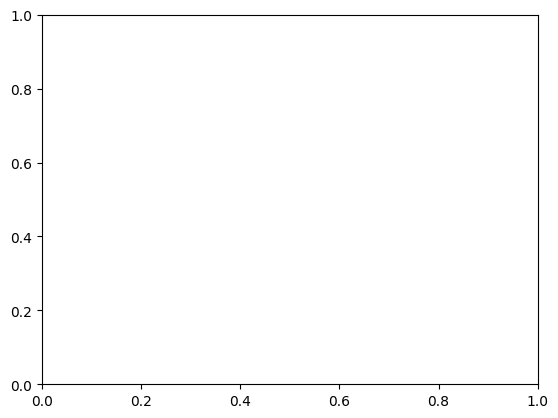

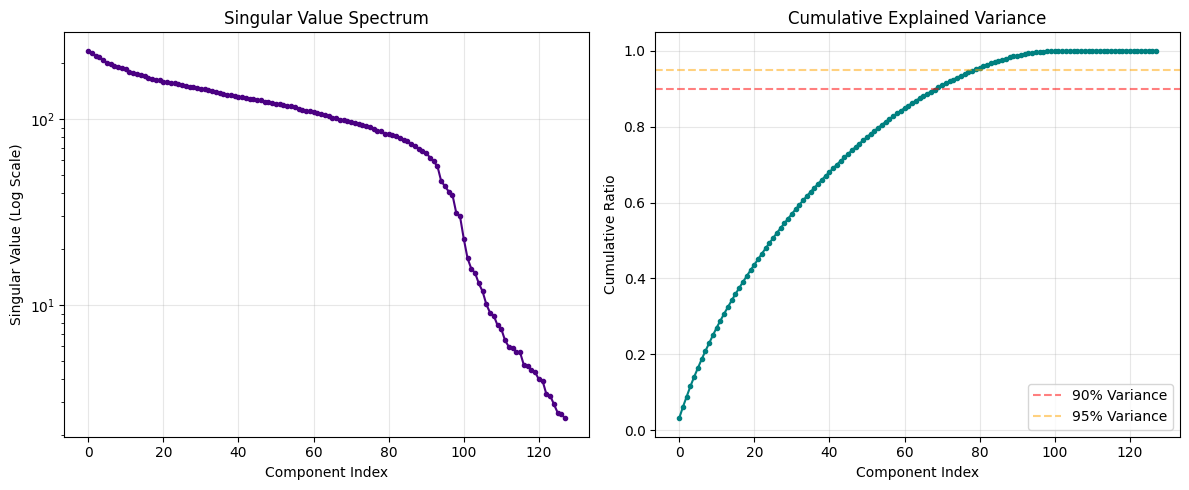

In [3]:

import torch
import torch.nn.functional as F
import numpy
import matplotlib.pyplot as plt


def sample_matching_features(z0, z1, M, num_points=32):
    # z0, z1 shape: (B, C, H_f, W_f)
    B, C, H_f, W_f = z0.shape

    # 1. Sample random coordinates P0 in range [-0.7, 0.7]
    p0 = torch.empty((B, num_points, 2), device=z0.device).uniform_(-0.7, 0.7)

    # 2. Convert P0 to homogeneous coordinates (B, num_points, 3, 1)
    p0_hom = torch.ones((B, num_points, 3, 1), device=z0.device)
    p0_hom[:, :, :2, 0] = p0

    # 3. Project points to transformed coordinate space: P1 = M @ P0
    p1_hom = torch.bmm(M, p0_hom.squeeze(-1).permute(0, 2, 1)).permute(0, 2, 1)
    p1 = p1_hom[:, :, :2]

    # 4. Extract features using grid_sample
    grid_p0 = p0.unsqueeze(1)
    grid_p1 = p1.unsqueeze(1) 

    feat0 = F.grid_sample(z0, grid_p0, align_corners=False).squeeze(2).permute(0, 2, 1)
    feat1 = F.grid_sample(z1, grid_p1, align_corners=False).squeeze(2).permute(0, 2, 1)

    # 5. Mask out points that landed outside valid normalized image frame [-1, 1]
    valid_mask = (p1[:, :, 0].abs() <= 1.0) & (p1[:, :, 1].abs() <= 1.0)

    return feat0, feat1, valid_mask


def collect_z_samples(n_samples, batch_size,  num_points = 32):

    width  = 256
    height = 256

    z_all_orig = []
    z_all_aug  = []

    for n in range(n_samples):
        # Assuming `dataset`, `AILibs`, and `model` are defined in your environment
        x = dataset.get_batch(batch_size)
        x = AILibs.resize_augmentation(x, width, height)
        x = numpy.array(x, dtype=numpy.float32)
        x = torch.from_numpy(x)

        x_aug = AILibs.photometric_augmentations(x, 0.5)

        M, M_inv = AILibs.generate_affine_matrices(batch_size)
        x_aug = AILibs.affine_augmentation(x_aug, M_inv)

        with torch.no_grad():
            z_orig = model(x)
            z_aug = model(x_aug)

        z_orig_, z_aug_, valid_mask = sample_matching_features(z_orig, z_aug, M, num_points)
    
        valid_z_orig = z_orig_[valid_mask]
        valid_z_aug  = z_aug_[valid_mask]

        z_all_orig.extend(valid_z_orig)
        z_all_aug.extend(valid_z_aug) 

        print("collecting ", n,  len(z_all_orig))


    z_all_orig = torch.stack(z_all_orig)
    z_all_aug  = torch.stack(z_all_aug)
    
    return z_all_orig, z_all_aug

za, zb = collect_z_samples(n_samples = 16, batch_size = 32,  num_points = 32)

za = za.detach().cpu().float().numpy()
zb = zb.detach().cpu().float().numpy()

print(za.shape, zb.shape)   


AILibs.eda.features_similarity(za, zb, experiment_path + "/eda/")
AILibs.eda.features_svd_spectrum(za, None, experiment_path + "/eda/")




In [4]:

def collect_z_samples_augs(n_samples, num_augs,  num_points = 32, num_samples = 100):

    width  = 256
    height = 256

    z_all_orig = []
    z_all_aug  = []

    for n in range(n_samples):
        # Assuming `dataset`, `AILibs`, and `model` are defined in your environment
        x = dataset.get_batch(1)
        x = AILibs.resize_augmentation(x, width, height)
        x = numpy.array(x, dtype=numpy.float32)
        x = torch.from_numpy(x)


        z_sample_orig = []
        z_sample_aug  = []

        for m in range(num_augs):
            x_aug = AILibs.photometric_augmentations(x, 0.5)

            M, M_inv = AILibs.generate_affine_matrices(1)
            x_aug = AILibs.affine_augmentation(x_aug, M_inv)

            with torch.no_grad():
                z_orig = model(x)
                z_aug = model(x_aug)

            z_orig_, z_aug_, valid_mask = sample_matching_features(z_orig, z_aug, M, num_points)
        
            valid_z_orig = z_orig_[valid_mask]
            valid_z_aug  = z_aug_[valid_mask]   

            z_sample_orig.extend(valid_z_orig)
            z_sample_aug.extend(valid_z_aug) 

        z_sample_orig = torch.stack(z_sample_orig)
        z_sample_aug  = torch.stack(z_sample_aug)

        indices = torch.randint(0, z_sample_orig.shape[0], (num_samples, ))

        z_sample_orig = z_sample_orig[indices]
        z_sample_aug  = z_sample_aug[indices]

        z_all_orig.append(z_sample_orig)
        z_all_aug.append(z_sample_aug)

        print("collecting ", n,  len(z_all_orig))

    z_all_orig = torch.stack(z_all_orig)
    z_all_aug  = torch.stack(z_all_aug)

    print(z_all_orig.shape, z_all_aug.shape)

    return  z_all_orig, z_all_aug
    

za, zb = collect_z_samples_augs(10, 64, num_points = 32) 

AILibs.analyze_augmentation_features(zb, experiment_path + "/eda/")
    

collecting  0 1
collecting  1 2
collecting  2 3
collecting  3 4
collecting  4 5
collecting  5 6
collecting  6 7
collecting  7 8
collecting  8 9
collecting  9 10
torch.Size([10, 100, 128]) torch.Size([10, 100, 128])


/opt/homebrew/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


'# Augmentation Feature Embedding & Cluster Report\n\n## 1. Batch & Feature Metadata\n- **Num Independent Samples (Classes):** `10`\n- **Num Augmentations per Sample:** `100`\n- **Num Feature Dimensions:** `128`\n- **Total Feature Vectors:** `1000`\n\n## 2. Augmentation Similarity & Distance Distributions\n| Metric | Pair Type | Mean | Std Dev | 5th Percentile | 95th Percentile | Sample Count |\n|---|---|---|---|---|---|---|\n| **Cosine Similarity** | Positive (Augmentations) | 0.1109 | 0.2816 | -0.1916 | 0.6987 | 99000 |\n| **Cosine Similarity** | Negative (Other Images) | -0.0005 | 0.1145 | -0.1356 | 0.2245 | 100000 |\n| **Euclidean Distance** | Positive (Augmentations) | 13.7635 | 3.0691 | 8.1066 | 18.2457 | 99000 |\n| **Euclidean Distance** | Negative (Other Images) | 14.8420 | 1.9246 | 11.6528 | 17.9810 | 100000 |\n\n## 3. Cluster Recovery & Manifold Analysis\n- **Expected Clusters (K):** `10`\n- **Adjusted Rand Index (ARI):** `0.1205`\n- **Normalized Mutual Information (NMI):** `

In [5]:
#x = cv2.imread(experiment_path + "cat.png")
#px = 220
#py = 520

x = cv2.imread(experiment_path + "cars.png")
#px = 220
#py = 820

px = 1400
py = 1100


x = numpy.array(x/255.0, dtype=numpy.float32)
x = numpy.moveaxis(x, 2, 0)

z = model(torch.from_numpy(x).unsqueeze(0).float())
z = z.squeeze(0).detach().cpu().numpy()

zc = z[:, py//8, px//8]
zc = numpy.expand_dims(zc, 0)


z_tmp = z.reshape((z.shape[0], z.shape[1]*z.shape[2])).T

z_sim = (z_tmp*zc).mean(axis=-1)

z_sim_min = z_sim.min()
z_sim_max = z_sim.max()

z_sim = (z_sim - z_sim_min)/(z_sim_max - z_sim_min)


z_sim = z_sim.reshape((z.shape[1], z.shape[2]))
z_sim = numpy.expand_dims(z_sim, 2)

z_mask = numpy.tile(z_sim, 3)



x_img = numpy.moveaxis(x, 0, 2)

print(x_img.shape)
print(z_sim.shape)
print(z_mask.shape)


z_mask = cv2.resize(z_mask, (x_img.shape[1], x_img.shape[0]))

print(z_mask.shape)

result_img = numpy.concatenate([x_img, z_mask], axis=1)

result_img= cv2.circle(result_img, (px, py), 80, (1, 0, 0), 5 )
cv2.imwrite("img_car.png", numpy.array(result_img*255, dtype=numpy.uint8))



[ WARN:0@50.017] global loadsave.cpp:278 findDecoder imread_('results/images_features_b/cars.png'): can't open/read file: check file path/integrity


TypeError: unsupported operand type(s) for /: 'NoneType' and 'float'